In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
product_summary = pd.read_csv("../data/processed/nlp_product_summary.csv")
product_summary.head(5)

,primary_category,secondary_category,product_id,brand_name,product_name,avg_rating,rating_count,avg_sentiment,positive_ratio,negative_ratio,price
0,Skincare,Cleansers,P122651,CLINIQUE,Clarifying Lotion 1,4.594737,190,0.905025,0.931579,0.068421,20.0
1,Skincare,Cleansers,P122661,CLINIQUE,7 Day Face Scrub Cream Rinse-Off Formula,4.596078,765,0.923623,0.939869,0.060131,26.0
2,Skincare,Cleansers,P122718,CLINIQUE,Exfoliating Face Scrub,4.653747,1161,0.935862,0.953488,0.046512,26.0
3,Skincare,Cleansers,P122762,CLINIQUE,Rinse-Off Foaming Cleanser,4.565773,783,0.915367,0.934866,0.065134,23.5
4,Skincare,Cleansers,P122876,CLINIQUE,Clarifying Lotion 4,4.512077,207,0.898423,0.932367,0.067633,20.0


In [3]:
df = product_summary.copy()

In [4]:
features = ["avg_rating", "rating_count", "avg_sentiment", "positive_ratio", "negative_ratio", "price"]

X = df[features].fillna(0)

In [5]:
# 3) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# 4) KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [7]:
# 5) Cluster özetleri
cluster_summary = df.groupby("cluster")[features].mean().round(3)
print(cluster_summary)

         avg_rating  rating_count  avg_sentiment  positive_ratio  \
cluster                                                            
0             3.246        82.539          0.604           0.591   
1             4.091       390.756          0.812           0.824   
2             4.591       500.339          0.933           0.949   

         negative_ratio   price  
cluster                          
0                 0.409  79.700  
1                 0.176  50.484  
2                 0.051  61.951  


In [8]:
# 6) En iyi cluster'ı seç
# Mantık: avg_rating ve avg_sentiment yüksek, negative_ratio düşük olsun
cluster_score = (cluster_summary["avg_rating"] + cluster_summary["avg_sentiment"] + cluster_summary["positive_ratio"] - cluster_summary["negative_ratio"])

best_cluster = cluster_score.idxmax()
print("Best cluster:", best_cluster)

Best cluster: 2


In [9]:
# 7) PCA ile 1 boyutlu skor
pca = PCA(n_components=1, random_state=42)
df["pca_score_raw"] = pca.fit_transform(X_scaled)

In [10]:
# 8) Skoru daha anlaşılır yapmak için 0-100 aralığına çek
min_score = df["pca_score_raw"].min()
max_score = df["pca_score_raw"].max()

df["pca_score"] = 100 * (df["pca_score_raw"] - min_score) / (max_score - min_score)

In [11]:
recommendation_table = df[[
    "primary_category",
    "secondary_category",
    "product_id",
    "brand_name",
    "product_name",
    "avg_rating",
    "rating_count",
    "avg_sentiment",
    "positive_ratio",
    "negative_ratio",
    "price",
    "cluster",
    "pca_score"
]].copy()

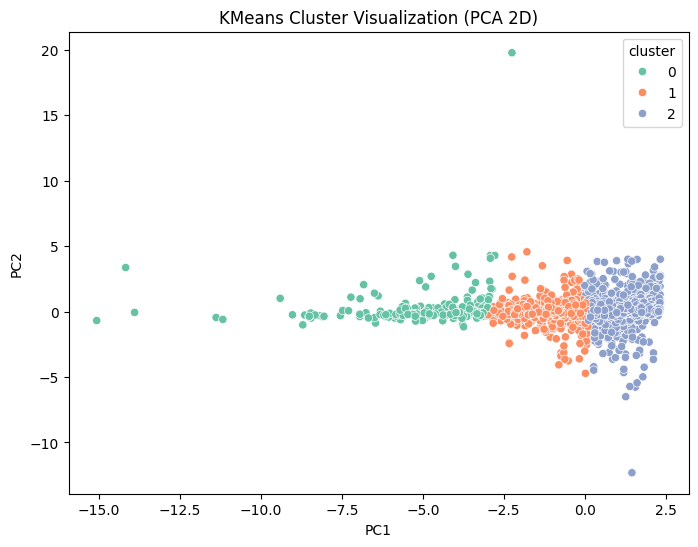

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plot_df = df.copy()
plot_df["PC1"] = X_pca_2d[:, 0]
plot_df["PC2"] = X_pca_2d[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("KMeans Cluster Visualization (PCA 2D)")
plt.show()

In [13]:
recommendation_table.to_csv("../data/processed/ml_recommendation_table.csv", index=False)